# Tilte : Evaluating Machine Learning Models for Fake Review Detection Using TF-IDF Representation, Textual Analysis, Explainable Machine Learning, and Prototype Development

# Importing Libraries and Basic Few Operations 

In [1]:
# I imported the NumPy library to perform numerical computations.
import numpy as np

# I imported the Pandas library to load and manipulate the dataset.
import pandas as pd

# I imported the Matplotlib library to create visualizations.
import matplotlib.pyplot as plt

# I imported the Seaborn library to generate statistical visualizations.
import seaborn as sns

# I loaded the fake reviews dataset into a DataFrame.
df = pd.read_csv("fake reviews dataset.csv")

# I displayed the first five records of the dataset to perform an initial inspection.
print(df.head())

# I displayed the shape of the dataset to determine the number of rows and columns.
print(df.shape)

# I displayed the column names of the dataset to understand its structure.
print(df.columns)

             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information on how to use it, but it i...  
4  Very nice set. Good quality. We have had the s...  
(40432, 4)
Index(['category', 'rating', 'label', 'text_'], dtype='object')


# Data Inspection 

In [2]:
# I displayed detailed information about the dataset to understand its structure, data types, and missing values.
df.info()

# I displayed the total number of observations (rows) in the dataset.
print("Number of Observations:", df.shape[0])

# I displayed the total number of columns in the dataset.
print("Number of Columns:", df.shape[1])

# I displayed the names of all columns present in the dataset.
print("Column Names:")
print(df.columns.tolist())

# I identified the target variable used for prediction.
target_variable = "label"

# I displayed the name of the target variable.
print("Target Variable:", target_variable)

# I identified the independent variables by excluding the target variable.
independent_variables = df.drop(columns=[target_variable]).columns.tolist()

# I displayed the names of the independent variables.
print("Independent Variables:")
print(independent_variables)

# I displayed the data type of each column to distinguish between numerical and categorical attributes.
print(df.dtypes)

# I displayed the statistical summary of the numerical columns.
print(df.describe())

# I displayed the statistical summary of all columns, including categorical attributes.
print(df.describe(include='all'))

# I counted the missing values in each column to identify incomplete data.
print(df.isnull().sum())

# I counted the duplicate records in the dataset.
print("Duplicate Records:", df.duplicated().sum())

# I counted the number of unique values present in each column.
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB
Number of Observations: 40432
Number of Columns: 4
Column Names:
['category', 'rating', 'label', 'text_']
Target Variable: label
Independent Variables:
['category', 'rating', 'text_']
category     object
rating      float64
label        object
text_        object
dtype: object
             rating
count  40432.000000
mean       4.256579
std        1.144354
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        5.000000
              category        rating  label  \
count            40432  40432.000000  40432   
unique              10           NaN      2   
top    

# Data Pre-processing 

In [3]:
# I counted the missing values present in each column of the dataset before data pre-processing.
print("Missing Values Before Removal:")
print(df.isnull().sum())

# I removed the rows containing missing values from the dataset.
df = df.dropna()

# I counted the missing values again to verify that they had been removed successfully.
print("\nMissing Values After Removal:")
print(df.isnull().sum())

# I counted the duplicate records present in the dataset before data pre-processing.
print("\nDuplicate Records Before Removal:", df.duplicated().sum())

# I removed the duplicate records from the dataset.
df = df.drop_duplicates()

# I counted the duplicate records again to verify that they had been removed successfully.
print("Duplicate Records After Removal:", df.duplicated().sum())

# I displayed the shape of the dataset after completing the data pre-processing stage.
print("\nDataset Shape After Data Pre-processing:", df.shape)

Missing Values Before Removal:
category    0
rating      0
label       0
text_       0
dtype: int64

Missing Values After Removal:
category    0
rating      0
label       0
text_       0
dtype: int64

Duplicate Records Before Removal: 12
Duplicate Records After Removal: 0

Dataset Shape After Data Pre-processing: (40420, 4)


# Exploratory Data Analysis 

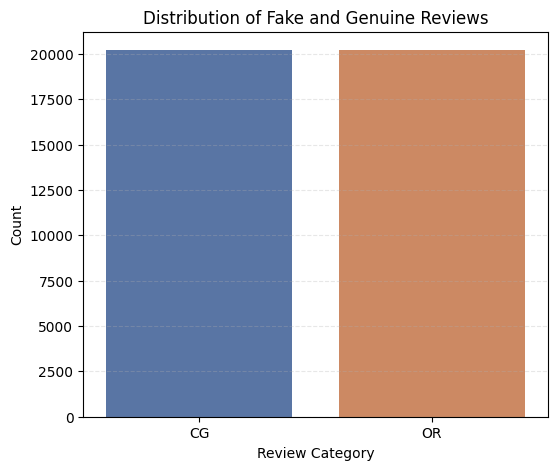

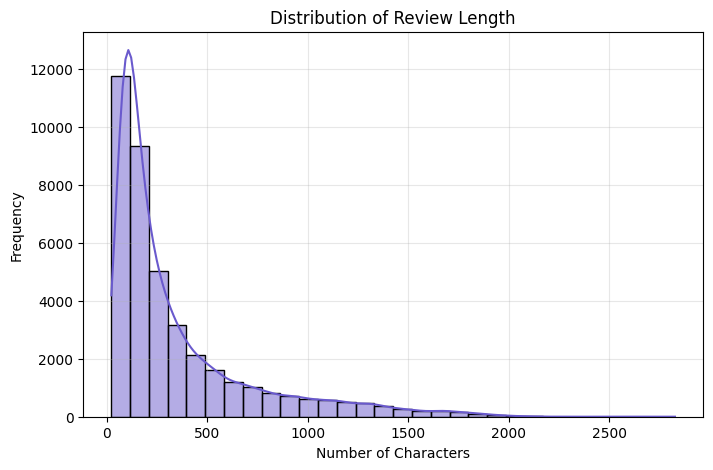

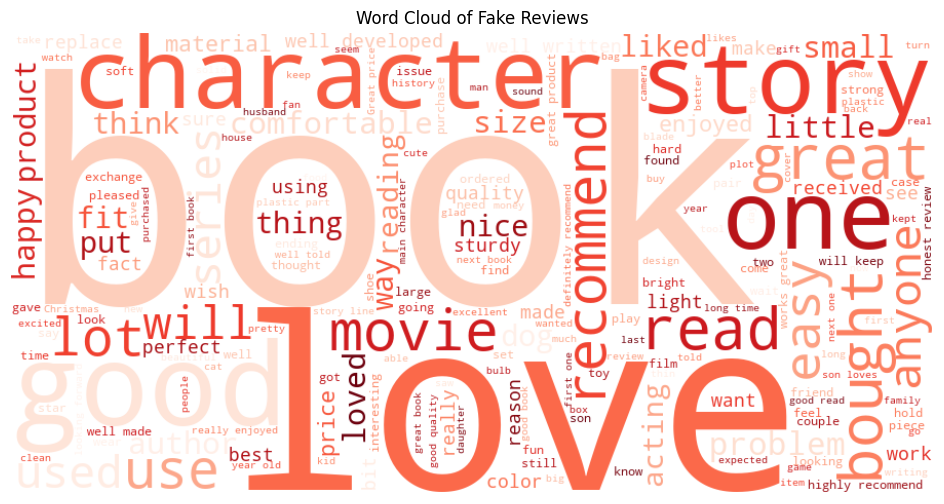

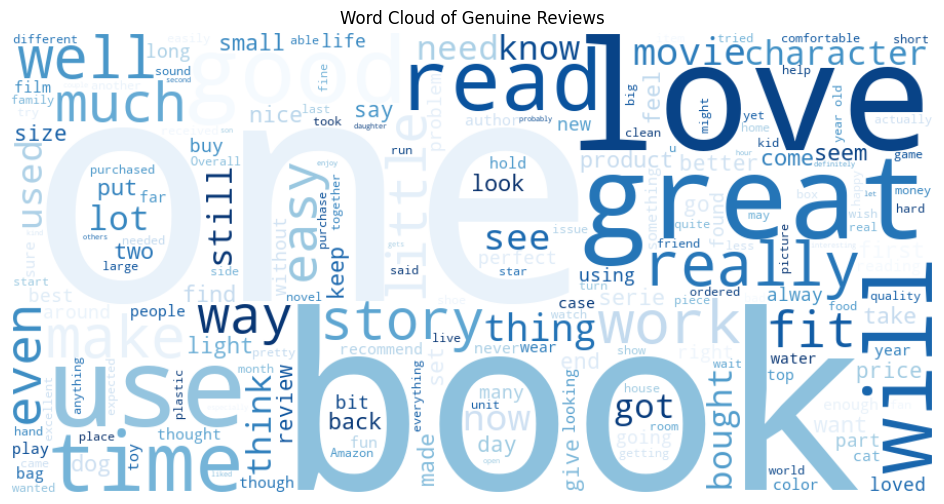

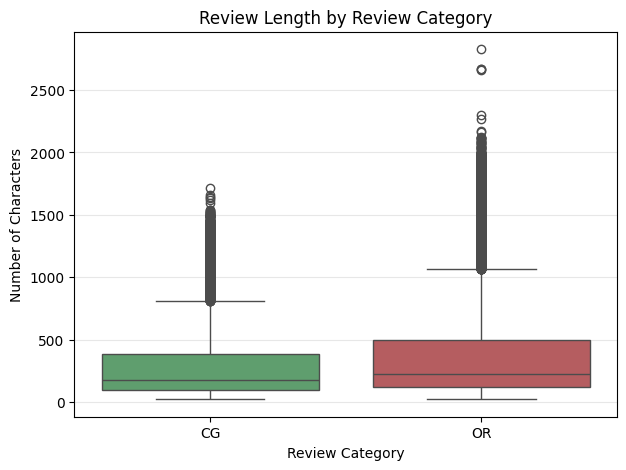

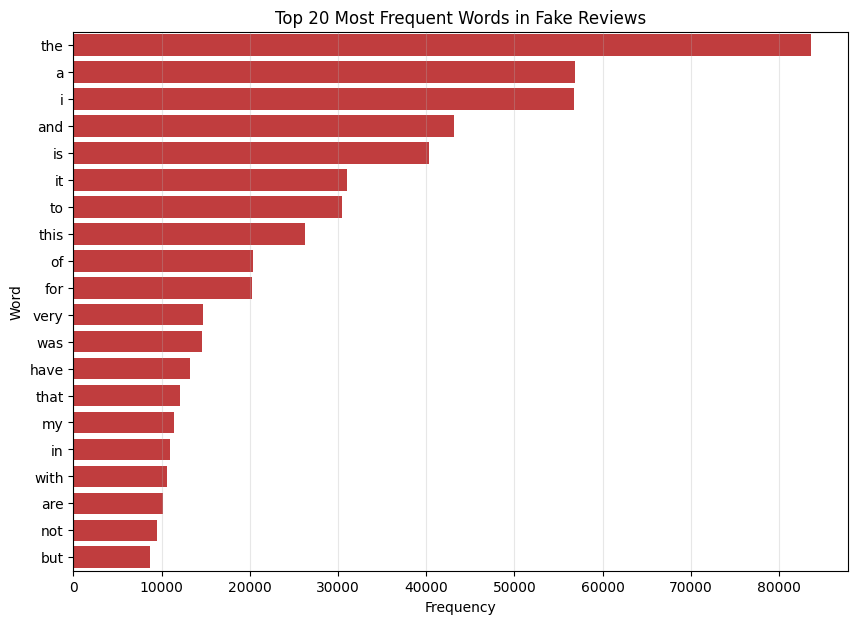

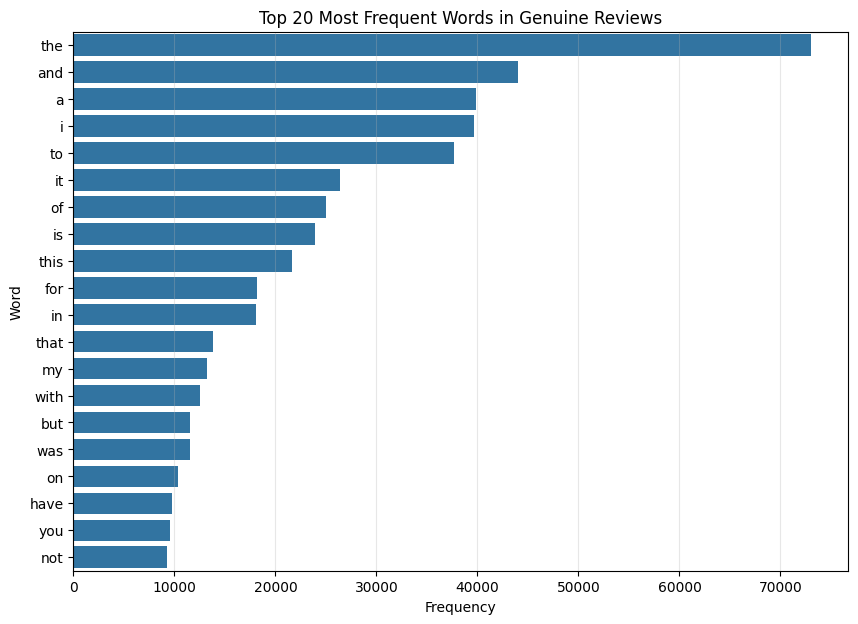

In [4]:
# I installed the WordCloud library.
!pip install wordcloud

# I imported the required libraries.
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import pandas as pd

# I created a new figure for the first visualization.
plt.figure(figsize=(6,5))

# I plotted the distribution of fake and genuine reviews.
sns.countplot(
    x="label",
    data=df,
    hue="label",
    palette=["#4C72B0", "#DD8452"],
    legend=False
)

# I added the title.
plt.title("Distribution of Fake and Genuine Reviews")

# I labelled the x-axis.
plt.xlabel("Review Category")

# I labelled the y-axis.
plt.ylabel("Count")

# I added grid lines.
plt.grid(axis="y", linestyle="--", alpha=0.3)

# I displayed the plot.
plt.show()


# I calculated the length of each review.
df["Review_Length"] = df["text_"].astype(str).str.len()

# I created a new figure for the second visualization.
plt.figure(figsize=(8,5))

# I plotted the distribution of review lengths.
sns.histplot(
    df["Review_Length"],
    bins=30,
    kde=True,
    color="#6A5ACD"
)

# I added the title.
plt.title("Distribution of Review Length")

# I labelled the x-axis.
plt.xlabel("Number of Characters")

# I labelled the y-axis.
plt.ylabel("Frequency")

# I added grid lines.
plt.grid(alpha=0.3)

# I displayed the plot.
plt.show()


# I combined all fake review text into a single string.
fake_reviews = " ".join(
    df[df["label"] == "CG"]["text_"].astype(str)
)

# I generated the word cloud for fake reviews.
fake_wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    colormap="Reds"
).generate(fake_reviews)

# I created a new figure.
plt.figure(figsize=(12,6))

# I displayed the fake review word cloud.
plt.imshow(fake_wordcloud, interpolation="bilinear")

# I removed the axes.
plt.axis("off")

# I added the title.
plt.title("Word Cloud of Fake Reviews")

# I displayed the plot.
plt.show()


# I combined all genuine review text into a single string.
genuine_reviews = " ".join(
    df[df["label"] == "OR"]["text_"].astype(str)
)

# I generated the word cloud for genuine reviews.
genuine_wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    colormap="Blues"
).generate(genuine_reviews)

# I created a new figure.
plt.figure(figsize=(12,6))

# I displayed the genuine review word cloud.
plt.imshow(genuine_wordcloud, interpolation="bilinear")

# I removed the axes.
plt.axis("off")

# I added the title.
plt.title("Word Cloud of Genuine Reviews")

# I displayed the plot.
plt.show()


# I created a new figure for the fifth visualization.
plt.figure(figsize=(7,5))

# I plotted the review length for each review category.
sns.boxplot(
    x="label",
    y="Review_Length",
    data=df,
    hue="label",
    palette=["#55A868", "#C44E52"],
    legend=False
)

# I added the title.
plt.title("Review Length by Review Category")

# I labelled the x-axis.
plt.xlabel("Review Category")

# I labelled the y-axis.
plt.ylabel("Number of Characters")

# I added grid lines.
plt.grid(axis="y", alpha=0.3)

# I displayed the plot.
plt.show()


# I counted the frequency of words appearing in fake reviews.
fake_word_counts = Counter(fake_reviews.lower().split())

# I selected the twenty most frequent words.
fake_top20 = pd.DataFrame(
    fake_word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

# I created a new figure.
plt.figure(figsize=(10,7))

# I plotted the top twenty words in fake reviews.
sns.barplot(
    data=fake_top20,
    x="Frequency",
    y="Word",
    color="#D62728"
)

# I added the title.
plt.title("Top 20 Most Frequent Words in Fake Reviews")

# I labelled the x-axis.
plt.xlabel("Frequency")

# I labelled the y-axis.
plt.ylabel("Word")

# I added grid lines.
plt.grid(axis="x", alpha=0.3)

# I displayed the plot.
plt.show()


# I counted the frequency of words appearing in genuine reviews.
genuine_word_counts = Counter(genuine_reviews.lower().split())

# I selected the twenty most frequent words.
genuine_top20 = pd.DataFrame(
    genuine_word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

# I created a new figure.
plt.figure(figsize=(10,7))

# I plotted the top twenty words in genuine reviews.
sns.barplot(
    data=genuine_top20,
    x="Frequency",
    y="Word",
    color="#1F77B4"
)

# I added the title.
plt.title("Top 20 Most Frequent Words in Genuine Reviews")

# I labelled the x-axis.
plt.xlabel("Frequency")

# I labelled the y-axis.
plt.ylabel("Word")

# I added grid lines.
plt.grid(axis="x", alpha=0.3)

# I displayed the plot.
plt.show()

# Text Pre-Processing 

In [5]:
# I imported the required libraries for text pre-processing.
import re
import nltk

# I imported the English stop words.
from nltk.corpus import stopwords

# I imported the WordNet lemmatizer.
from nltk.stem import WordNetLemmatizer

# I downloaded the required NLTK resources.
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# I initialized the English stop words.
stop_words = set(stopwords.words("english"))

# I initialized the WordNet lemmatizer.
lemmatizer = WordNetLemmatizer()

# I defined a function to clean and preprocess the review text.
def preprocess_text(text):

    # I converted the input into a string.
    text = str(text)

    # I converted the text into lowercase.
    text = text.lower()

    # I removed URLs from the text.
    text = re.sub(r"http\S+|www\S+", "", text)

    # I removed HTML tags from the text.
    text = re.sub(r"<.*?>", "", text)

    # I removed numbers from the text.
    text = re.sub(r"\d+", "", text)

    # I removed punctuation and special characters from the text.
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # I removed extra white spaces from the text.
    text = re.sub(r"\s+", " ", text).strip()

    # I split the text into individual words.
    words = text.split()

    # I removed stop words and applied lemmatization.
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # I joined the processed words into a single sentence.
    return " ".join(words)

# I applied the text pre-processing function to the review text column.
df["Processed_Review"] = df["text_"].apply(preprocess_text)

# I displayed the first five original and processed reviews.
print(df[["text_", "Processed_Review"]].head())

# I displayed the first processed review.
print("\nFirst Processed Review:")
print(df["Processed_Review"].iloc[0])

# I displayed the total number of processed reviews.
print("\nTotal Processed Reviews:", len(df["Processed_Review"]))

# I displayed the shape of the dataset after text pre-processing.
print("\nDataset Shape After Text Pre-processing:", df.shape)

# I counted the missing values in the processed review column.
print("\nMissing Values in Processed Reviews:")
print(df["Processed_Review"].isnull().sum())

# I displayed the average number of words in the processed reviews.
average_words = df["Processed_Review"].apply(lambda x: len(x.split())).mean()

print("\nAverage Number of Words per Processed Review:")
print(round(average_words, 2))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tiruv\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tiruv\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\tiruv\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                               text_  \
0  Love this!  Well made, sturdy, and very comfor...   
1  love it, a great upgrade from the original.  I...   
2  This pillow saved my back. I love the look and...   
3  Missing information on how to use it, but it i...   
4  Very nice set. Good quality. We have had the s...   

                                    Processed_Review  
0  love well made sturdy comfortable love itvery ...  
1   love great upgrade original ive mine couple year  
2            pillow saved back love look feel pillow  
3        missing information use great product price  
4                nice set good quality set two month  

First Processed Review:
love well made sturdy comfortable love itvery pretty

Total Processed Reviews: 40420

Dataset Shape After Text Pre-processing: (40420, 6)

Missing Values in Processed Reviews:
0

Average Number of Words per Processed Review:
31.58


In [6]:
# I imported the TF-IDF vectorizer.
from sklearn.feature_extraction.text import TfidfVectorizer

# I initialized the TF-IDF vectorizer with a maximum of 5000 features.
tfidf = TfidfVectorizer(
    max_features=5000
)

# I converted the processed review text into TF-IDF feature vectors.
X = tfidf.fit_transform(df["Processed_Review"])

# I selected the target variable for classification.
y = df["label"]

# I displayed the shape of the TF-IDF feature matrix.
print("TF-IDF Feature Matrix Shape:", X.shape)

# I displayed the shape of the target variable.
print("Target Variable Shape:", y.shape)

# I displayed the total number of extracted TF-IDF features.
print("\nTotal Number of TF-IDF Features:")
print(len(tfidf.get_feature_names_out()))

# I displayed the first twenty extracted TF-IDF feature names.
print("\nFirst 20 TF-IDF Features:")
print(tfidf.get_feature_names_out()[:20])

# I displayed the last twenty extracted TF-IDF feature names.
print("\nLast 20 TF-IDF Features:")
print(tfidf.get_feature_names_out()[-20:])

# I converted only the first five TF-IDF vectors into a DataFrame for inspection.
sample_tfidf = pd.DataFrame(
    X[:5].toarray(),
    columns=tfidf.get_feature_names_out()
)

# I displayed the first five rows of the TF-IDF feature matrix.
print("\nFirst Five Rows of the TF-IDF Feature Matrix:")
print(sample_tfidf)

# I displayed the shape of the sample TF-IDF DataFrame.
print("\nSample TF-IDF DataFrame Shape:")
print(sample_tfidf.shape)

# I displayed the number of non-zero TF-IDF values.
print("\nNumber of Non-Zero TF-IDF Values:")
print(X.nnz)

# I calculated the sparsity of the TF-IDF matrix.
sparsity = 100 * (1 - X.nnz / (X.shape[0] * X.shape[1]))

# I displayed the sparsity of the TF-IDF matrix.
print("\nTF-IDF Matrix Sparsity: {:.2f}%".format(sparsity))

# I displayed the data type of the TF-IDF matrix.
print("\nTF-IDF Matrix Type:")
print(type(X))

TF-IDF Feature Matrix Shape: (40420, 5000)
Target Variable Shape: (40420,)

Total Number of TF-IDF Features:
5000

First 20 TF-IDF Features:
['aa' 'aaa' 'aaron' 'ab' 'abandoned' 'abbey' 'ability' 'able' 'abrupt'
 'abruptly' 'absolute' 'absolutely' 'absorb' 'absorbent' 'abuse' 'abused'
 'abusive' 'ac' 'academic' 'academy']

Last 20 TF-IDF Features:
['yorkie' 'youd' 'youi' 'youll' 'young' 'younger' 'youngest' 'youre'
 'youth' 'youtube' 'youve' 'yr' 'zero' 'zip' 'zipper' 'zippered' 'zoe'
 'zombie' 'zone' 'zoom']

First Five Rows of the TF-IDF Feature Matrix:
    aa  aaa  aaron   ab  abandoned  abbey  ability  able  abrupt  abruptly  \
0  0.0  0.0    0.0  0.0        0.0    0.0      0.0   0.0     0.0       0.0   
1  0.0  0.0    0.0  0.0        0.0    0.0      0.0   0.0     0.0       0.0   
2  0.0  0.0    0.0  0.0        0.0    0.0      0.0   0.0     0.0       0.0   
3  0.0  0.0    0.0  0.0        0.0    0.0      0.0   0.0     0.0       0.0   
4  0.0  0.0    0.0  0.0        0.0    0.0      0

# Splitting the Dataset 

In [7]:
# I imported the train-test split function.
from sklearn.model_selection import train_test_split

# I divided the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# I displayed the shape of the training feature matrix.
print("Training Feature Matrix Shape:", X_train.shape)

# I displayed the shape of the testing feature matrix.
print("Testing Feature Matrix Shape:", X_test.shape)

# I displayed the shape of the training target variable.
print("Training Target Shape:", y_train.shape)

# I displayed the shape of the testing target variable.
print("Testing Target Shape:", y_test.shape)

# I displayed the class distribution of the training dataset.
print("\nTraining Class Distribution:")
print(y_train.value_counts())

# I displayed the class distribution of the testing dataset.
print(y_test.value_counts())

# I displayed the percentage distribution of the training dataset.
print("\nTraining Class Percentage:")
print(round(y_train.value_counts(normalize=True) * 100, 2))

# I displayed the percentage distribution of the testing dataset.
print("\nTesting Class Percentage:")
print(round(y_test.value_counts(normalize=True) * 100, 2))

Training Feature Matrix Shape: (32336, 5000)
Testing Feature Matrix Shape: (8084, 5000)
Training Target Shape: (32336,)
Testing Target Shape: (8084,)

Training Class Distribution:
label
OR    16172
CG    16164
Name: count, dtype: int64
label
OR    4043
CG    4041
Name: count, dtype: int64

Training Class Percentage:
label
OR    50.01
CG    49.99
Name: proportion, dtype: float64

Testing Class Percentage:
label
OR    50.01
CG    49.99
Name: proportion, dtype: float64


In [19]:
# I imported the required libraries.
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# I initialized the Logistic Regression classifier.
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# I trained the Logistic Regression model.
logistic_model.fit(
    X_train,
    y_train
)

# I predicted the class labels.
y_pred_logistic = logistic_model.predict(
    X_test
)

# I predicted the probability of the positive class (CG).
y_prob_logistic = logistic_model.predict_proba(
    X_test
)[:, 0]

# I calculated the Accuracy.
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

# I calculated the Precision.
logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    pos_label="CG"
)

# I calculated the Recall.
logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    pos_label="CG"
)

# I calculated the F1-score.
logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    pos_label="CG"
)

# I calculated the ROC-AUC score.
logistic_auc = roc_auc_score(
    (y_test == "CG").astype(int),
    y_prob_logistic
)

# I generated the classification report.
logistic_classification_report = classification_report(
    y_test,
    y_pred_logistic
)

# I generated the confusion matrix.
logistic_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Performance\n")

print(f"Accuracy  : {logistic_accuracy:.4f}")
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"F1-score  : {logistic_f1:.4f}")
print(f"ROC-AUC   : {logistic_auc:.4f}")

print("\nClassification Report\n")

print(logistic_classification_report)

# I stored the evaluation metrics separately.
logistic_accuracy_result = logistic_accuracy
logistic_precision_result = logistic_precision
logistic_recall_result = logistic_recall
logistic_f1_result = logistic_f1
logistic_auc_result = logistic_auc

Logistic Regression Performance

Accuracy  : 0.8695
Precision : 0.8749
Recall    : 0.8622
F1-score  : 0.8685
ROC-AUC   : 0.9429

Classification Report

              precision    recall  f1-score   support

          CG       0.87      0.86      0.87      4041
          OR       0.86      0.88      0.87      4043

    accuracy                           0.87      8084
   macro avg       0.87      0.87      0.87      8084
weighted avg       0.87      0.87      0.87      8084



In [17]:
# I imported the required libraries.
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# I initialized the Multinomial Naïve Bayes classifier.
naive_bayes_model = MultinomialNB()

# I trained the Multinomial Naïve Bayes model.
naive_bayes_model.fit(
    X_train,
    y_train
)

# I predicted the class labels.
y_pred_nb = naive_bayes_model.predict(
    X_test
)

# I predicted the probability of the positive class (CG).
y_prob_nb = naive_bayes_model.predict_proba(
    X_test
)[:, 0]

# I calculated the Accuracy.
nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

# I calculated the Precision.
nb_precision = precision_score(
    y_test,
    y_pred_nb,
    pos_label="CG"
)

# I calculated the Recall.
nb_recall = recall_score(
    y_test,
    y_pred_nb,
    pos_label="CG"
)

# I calculated the F1-score.
nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    pos_label="CG"
)

# I calculated the ROC-AUC score.
nb_auc = roc_auc_score(
    (y_test == "CG").astype(int),
    y_prob_nb
)

# I generated the classification report.
nb_classification_report = classification_report(
    y_test,
    y_pred_nb
)

# I generated the confusion matrix.
nb_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_nb
)

print("Multinomial Naïve Bayes Performance\n")

print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1-score  : {nb_f1:.4f}")
print(f"ROC-AUC   : {nb_auc:.4f}")

print("\nClassification Report\n")

print(nb_classification_report)

# I stored the evaluation metrics separately.
nb_accuracy_result = nb_accuracy
nb_precision_result = nb_precision
nb_recall_result = nb_recall
nb_f1_result = nb_f1
nb_auc_result = nb_auc

Multinomial Naïve Bayes Performance

Accuracy  : 0.8521
Precision : 0.8362
Recall    : 0.8755
F1-score  : 0.8554
ROC-AUC   : 0.9354

Classification Report

              precision    recall  f1-score   support

          CG       0.84      0.88      0.86      4041
          OR       0.87      0.83      0.85      4043

    accuracy                           0.85      8084
   macro avg       0.85      0.85      0.85      8084
weighted avg       0.85      0.85      0.85      8084



In [20]:
# I imported the required libraries.
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# I encoded the target labels for XGBoost.
y_train_xgb = (y_train == "CG").astype(int)

y_test_xgb = (y_test == "CG").astype(int)

# I initialized the XGBoost classifier.
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# I trained the XGBoost model.
xgb_model.fit(
    X_train,
    y_train_xgb
)

# I predicted the class labels.
y_pred_xgb = xgb_model.predict(
    X_test
)

# I converted the predicted labels to their original classes.
y_pred_xgb_labels = [
    "CG" if prediction == 1 else "OR"
    for prediction in y_pred_xgb
]

# I predicted the probability of the positive class (CG).
y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

# I calculated the Accuracy.
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb_labels
)

# I calculated the Precision.
xgb_precision = precision_score(
    y_test,
    y_pred_xgb_labels,
    pos_label="CG"
)

# I calculated the Recall.
xgb_recall = recall_score(
    y_test,
    y_pred_xgb_labels,
    pos_label="CG"
)

# I calculated the F1-score.
xgb_f1 = f1_score(
    y_test,
    y_pred_xgb_labels,
    pos_label="CG"
)

# I calculated the ROC-AUC score.
xgb_auc = roc_auc_score(
    y_test_xgb,
    y_prob_xgb
)

# I generated the classification report.
xgb_classification_report = classification_report(
    y_test,
    y_pred_xgb_labels
)

# I generated the confusion matrix.
xgb_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_xgb_labels
)

print("XGBoost Performance\n")

print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1-score  : {xgb_f1:.4f}")
print(f"ROC-AUC   : {xgb_auc:.4f}")

print("\nClassification Report\n")

print(xgb_classification_report)

# I stored the evaluation metrics separately.
xgb_accuracy_result = xgb_accuracy
xgb_precision_result = xgb_precision
xgb_recall_result = xgb_recall
xgb_f1_result = xgb_f1
xgb_auc_result = xgb_auc

XGBoost Performance

Accuracy  : 0.8382
Precision : 0.8548
Recall    : 0.8146
F1-score  : 0.8343
ROC-AUC   : 0.9260

Classification Report

              precision    recall  f1-score   support

          CG       0.85      0.81      0.83      4041
          OR       0.82      0.86      0.84      4043

    accuracy                           0.84      8084
   macro avg       0.84      0.84      0.84      8084
weighted avg       0.84      0.84      0.84      8084



In [21]:
# I imported the required libraries.
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# I initialized the Random Forest classifier.
rf_model = RandomForestClassifier(
    random_state=42
)

# I trained the Random Forest model.
rf_model.fit(
    X_train,
    y_train
)

# I predicted the class labels.
y_pred_rf = rf_model.predict(
    X_test
)

# I predicted the probability of the positive class (CG).
y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 0]

# I calculated the Accuracy.
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

# I calculated the Precision.
rf_precision = precision_score(
    y_test,
    y_pred_rf,
    pos_label="CG"
)

# I calculated the Recall.
rf_recall = recall_score(
    y_test,
    y_pred_rf,
    pos_label="CG"
)

# I calculated the F1-score.
rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    pos_label="CG"
)

# I calculated the ROC-AUC score.
rf_auc = roc_auc_score(
    (y_test == "CG").astype(int),
    y_prob_rf
)

# I generated the classification report.
rf_classification_report = classification_report(
    y_test,
    y_pred_rf
)

# I generated the confusion matrix.
rf_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Random Forest Performance\n")

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")

print("\nClassification Report\n")

print(rf_classification_report)

# I stored the evaluation metrics separately.
rf_accuracy_result = rf_accuracy
rf_precision_result = rf_precision
rf_recall_result = rf_recall
rf_f1_result = rf_f1
rf_auc_result = rf_auc

Random Forest Performance

Accuracy  : 0.8431
Precision : 0.8213
Recall    : 0.8770
F1-score  : 0.8483
ROC-AUC   : 0.9261

Classification Report

              precision    recall  f1-score   support

          CG       0.82      0.88      0.85      4041
          OR       0.87      0.81      0.84      4043

    accuracy                           0.84      8084
   macro avg       0.84      0.84      0.84      8084
weighted avg       0.84      0.84      0.84      8084



In [22]:
# I imported the required libraries.
import pandas as pd

# I created the comparative results table.
comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naïve Bayes",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy_result,
        nb_accuracy_result,
        rf_accuracy_result,
        xgb_accuracy_result
    ],
    "Precision": [
        logistic_precision_result,
        nb_precision_result,
        rf_precision_result,
        xgb_precision_result
    ],
    "Recall": [
        logistic_recall_result,
        nb_recall_result,
        rf_recall_result,
        xgb_recall_result
    ],
    "F1-score": [
        logistic_f1_result,
        nb_f1_result,
        rf_f1_result,
        xgb_f1_result
    ],
    "ROC-AUC": [
        logistic_auc_result,
        nb_auc_result,
        rf_auc_result,
        xgb_auc_result
    ]
})

# I rounded the values.
comparison_results = comparison_results.round(4)

print(comparison_results)

# I displayed the styled comparison table.
comparison_results.style\
    .hide(axis="index")\
    .background_gradient(
        cmap="YlGnBu",
        subset=[
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC"
        ]
    )\
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt"
    })\
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-size", "13pt"),
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])

                     Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0      Logistic Regression    0.8695     0.8749  0.8622    0.8685   0.9429
1  Multinomial Naïve Bayes    0.8521     0.8362  0.8755    0.8554   0.9354
2            Random Forest    0.8431     0.8213  0.8770    0.8483   0.9261
3                  XGBoost    0.8382     0.8548  0.8146    0.8343   0.9260


Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.869500,0.874900,0.862200,0.868500,0.942900
Multinomial Naïve Bayes,0.852100,0.836200,0.875500,0.855400,0.935400
Random Forest,0.843100,0.821300,0.877000,0.848300,0.926100
XGBoost,0.838200,0.854800,0.814600,0.834300,0.926000


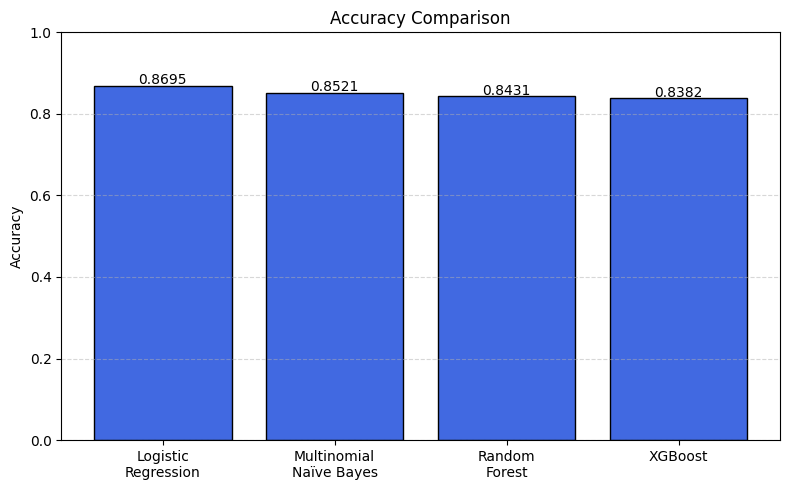

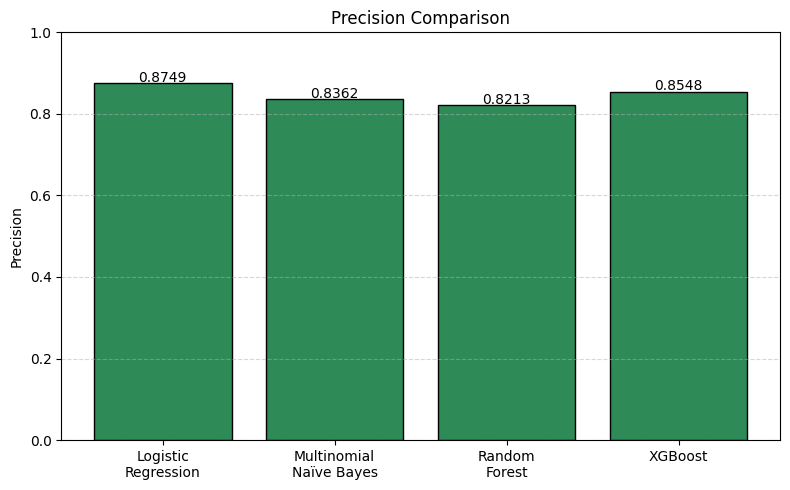

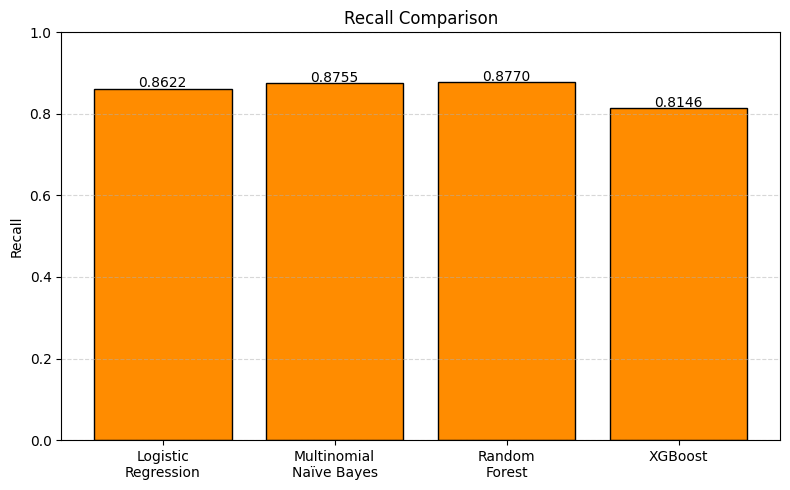

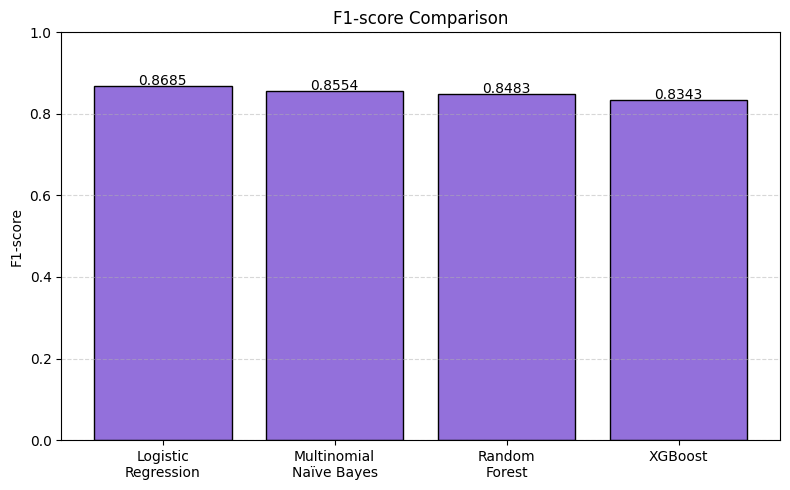

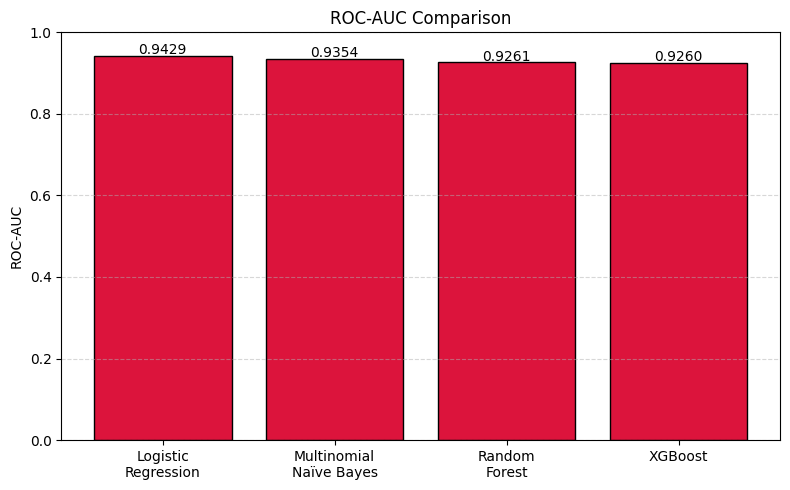

In [23]:
# I imported the required libraries.
import matplotlib.pyplot as plt

# I stored the model names.
models = [
    "Logistic\nRegression",
    "Multinomial\nNaïve Bayes",
    "Random\nForest",
    "XGBoost"
]

# I stored the evaluation metrics.
accuracy = [
    logistic_accuracy_result,
    nb_accuracy_result,
    rf_accuracy_result,
    xgb_accuracy_result
]

precision = [
    logistic_precision_result,
    nb_precision_result,
    rf_precision_result,
    xgb_precision_result
]

recall = [
    logistic_recall_result,
    nb_recall_result,
    rf_recall_result,
    xgb_recall_result
]

f1_score_values = [
    logistic_f1_result,
    nb_f1_result,
    rf_f1_result,
    xgb_f1_result
]

roc_auc = [
    logistic_auc_result,
    nb_auc_result,
    rf_auc_result,
    xgb_auc_result
]

# Accuracy
plt.figure(figsize=(8,5))

bars = plt.bar(
    models,
    accuracy,
    color="royalblue",
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10
    )

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Precision
plt.figure(figsize=(8,5))

bars = plt.bar(
    models,
    precision,
    color="seagreen",
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10
    )

plt.title("Precision Comparison")
plt.ylabel("Precision")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Recall
plt.figure(figsize=(8,5))

bars = plt.bar(
    models,
    recall,
    color="darkorange",
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10
    )

plt.title("Recall Comparison")
plt.ylabel("Recall")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# F1-score
plt.figure(figsize=(8,5))

bars = plt.bar(
    models,
    f1_score_values,
    color="mediumpurple",
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10
    )

plt.title("F1-score Comparison")
plt.ylabel("F1-score")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ROC-AUC
plt.figure(figsize=(8,5))

bars = plt.bar(
    models,
    roc_auc,
    color="crimson",
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10
    )

plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

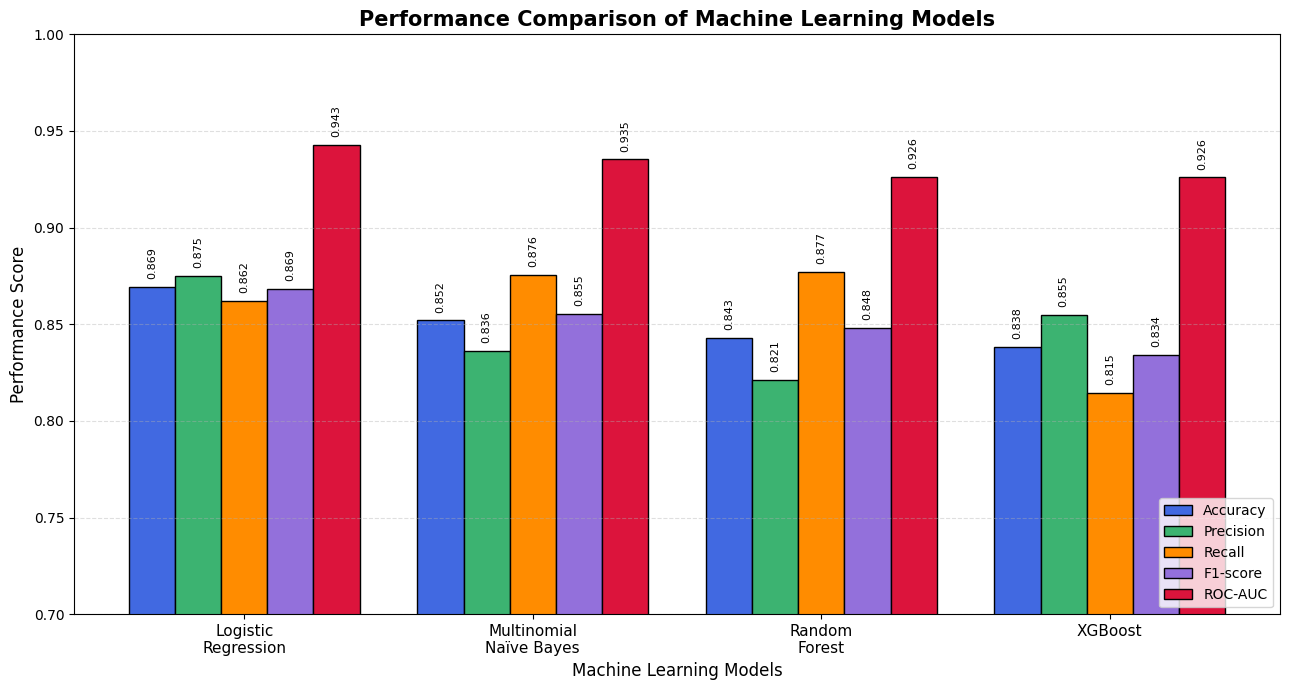

In [24]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I stored the model names.
models = [
    "Logistic\nRegression",
    "Multinomial\nNaïve Bayes",
    "Random\nForest",
    "XGBoost"
]

# I stored the evaluation metrics.
accuracy = [
    logistic_accuracy_result,
    nb_accuracy_result,
    rf_accuracy_result,
    xgb_accuracy_result
]

precision = [
    logistic_precision_result,
    nb_precision_result,
    rf_precision_result,
    xgb_precision_result
]

recall = [
    logistic_recall_result,
    nb_recall_result,
    rf_recall_result,
    xgb_recall_result
]

f1_score_values = [
    logistic_f1_result,
    nb_f1_result,
    rf_f1_result,
    xgb_f1_result
]

roc_auc = [
    logistic_auc_result,
    nb_auc_result,
    rf_auc_result,
    xgb_auc_result
]

# I created the grouped bar chart.
x = np.arange(len(models))

width = 0.16

plt.figure(figsize=(13,7))

plt.bar(
    x - 2*width,
    accuracy,
    width,
    label="Accuracy",
    color="royalblue",
    edgecolor="black"
)

plt.bar(
    x - width,
    precision,
    width,
    label="Precision",
    color="mediumseagreen",
    edgecolor="black"
)

plt.bar(
    x,
    recall,
    width,
    label="Recall",
    color="darkorange",
    edgecolor="black"
)

plt.bar(
    x + width,
    f1_score_values,
    width,
    label="F1-score",
    color="mediumpurple",
    edgecolor="black"
)

plt.bar(
    x + 2*width,
    roc_auc,
    width,
    label="ROC-AUC",
    color="crimson",
    edgecolor="black"
)

# I added the values above each bar.
for values, offset in zip(
    [accuracy, precision, recall, f1_score_values, roc_auc],
    [-2*width, -width, 0, width, 2*width]
):
    for i, value in enumerate(values):
        plt.text(
            x[i] + offset,
            value + 0.004,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

plt.xticks(
    x,
    models,
    fontsize=11
)

plt.ylabel(
    "Performance Score",
    fontsize=12
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=12
)

plt.title(
    "Performance Comparison of Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

plt.ylim(0.70, 1.00)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

plt.show()

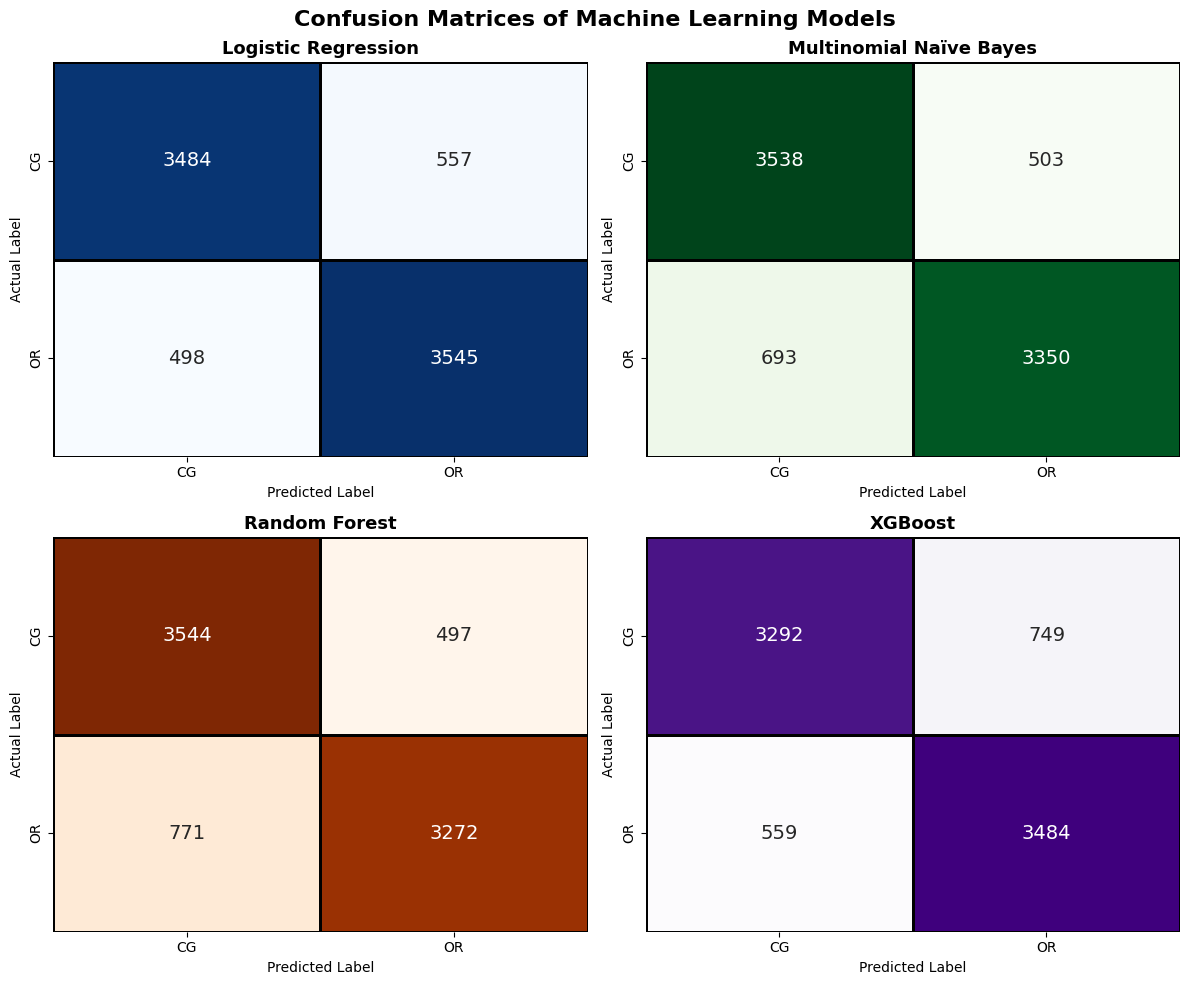

In [25]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# I created the figure.
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,10)
)

# Logistic Regression
sns.heatmap(
    logistic_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1,
    linecolor="black",
    xticklabels=["CG","OR"],
    yticklabels=["CG","OR"],
    annot_kws={"fontsize":14},
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Logistic Regression",
    fontsize=13,
    fontweight="bold"
)

axes[0,0].set_xlabel("Predicted Label")
axes[0,0].set_ylabel("Actual Label")

# Multinomial Naïve Bayes
sns.heatmap(
    nb_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    linewidths=1,
    linecolor="black",
    xticklabels=["CG","OR"],
    yticklabels=["CG","OR"],
    annot_kws={"fontsize":14},
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Multinomial Naïve Bayes",
    fontsize=13,
    fontweight="bold"
)

axes[0,1].set_xlabel("Predicted Label")
axes[0,1].set_ylabel("Actual Label")

# Random Forest
sns.heatmap(
    rf_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    linewidths=1,
    linecolor="black",
    xticklabels=["CG","OR"],
    yticklabels=["CG","OR"],
    annot_kws={"fontsize":14},
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Random Forest",
    fontsize=13,
    fontweight="bold"
)

axes[1,0].set_xlabel("Predicted Label")
axes[1,0].set_ylabel("Actual Label")

# XGBoost
sns.heatmap(
    xgb_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Purples",
    cbar=False,
    linewidths=1,
    linecolor="black",
    xticklabels=["CG","OR"],
    yticklabels=["CG","OR"],
    annot_kws={"fontsize":14},
    ax=axes[1,1]
)

axes[1,1].set_title(
    "XGBoost",
    fontsize=13,
    fontweight="bold"
)

axes[1,1].set_xlabel("Predicted Label")
axes[1,1].set_ylabel("Actual Label")

plt.suptitle(
    "Confusion Matrices of Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

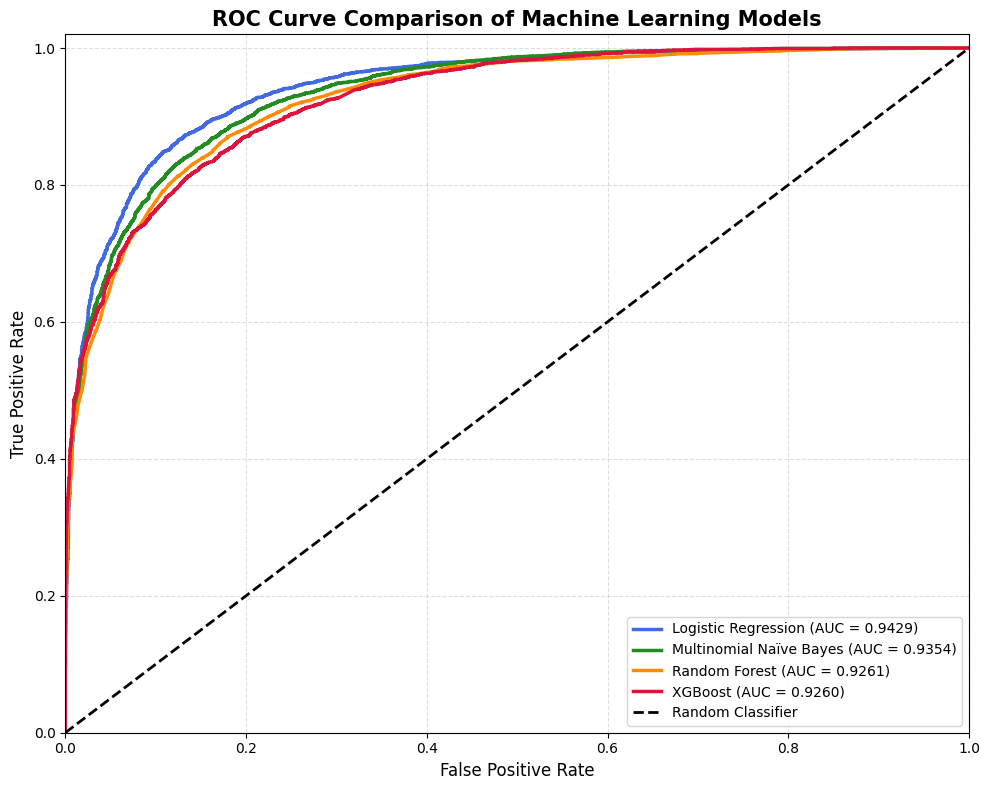

In [26]:
# I imported the required libraries.
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve

# I encoded the true labels.
y_test_binary = (y_test == "CG").astype(int)

# I calculated the ROC curve for Logistic Regression.
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test_binary,
    y_prob_logistic
)

# I calculated the ROC curve for Multinomial Naïve Bayes.
fpr_nb, tpr_nb, _ = roc_curve(
    y_test_binary,
    y_prob_nb
)

# I calculated the ROC curve for Random Forest.
fpr_rf, tpr_rf, _ = roc_curve(
    y_test_binary,
    y_prob_rf
)

# I calculated the ROC curve for XGBoost.
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test_binary,
    y_prob_xgb
)

# I created the ROC-AUC comparison figure.
plt.figure(figsize=(10,8))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    color="royalblue",
    linewidth=2.5,
    label=f"Logistic Regression (AUC = {logistic_auc:.4f})"
)

plt.plot(
    fpr_nb,
    tpr_nb,
    color="forestgreen",
    linewidth=2.5,
    label=f"Multinomial Naïve Bayes (AUC = {nb_auc:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    color="darkorange",
    linewidth=2.5,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    color="crimson",
    linewidth=2.5,
    label=f"XGBoost (AUC = {xgb_auc:.4f})"
)

# I plotted the random classifier.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Random Classifier"
)

plt.title(
    "ROC Curve Comparison of Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

plt.tight_layout()

plt.show()